## 前言
https://codetop.cc/home

力扣 算法 前100 高频考查题 

---

### 23. 合并 K 个升序链表
>给你一个链表数组，每个链表都已经按升序排列。请你将所有链表合并到一个升序链表中，返回合并后的链表。

- 思路。这和合并两个有序链表一样，归并排序也用这个函数。难点是如何设计保存合并后的链表以备和新的链表合并？从左往右边吃，最后只剩下一个。

 why is hard?

In [11]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
def mergeKLists(lists):
    def mergeTwoLists(l1,l2):
        tail = dummy = ListNode()
        while l1 and l2:
            if l1.val < l2.val:
                tail.next = l1
                l1 = l1.next
            else:
                tail.next = l2
                l2 = l2.next
            tail = tail.next
        tail.next = l1 if l1 else l2
        return dummy.next

    # 主逻辑
    # 设计的比较巧。0,1,->0,2 -> 0,4。通过step控制, 分治的思想.
    # step的设计是个模版
    step = 1
    while step<len(lists):
        for i in range(0,len(lists)-step,step*2):
            lists[i] = mergeTwoLists(lists[i], lists[i+step])
        step *= 2
        
    return lists[0]
    
    
# lists = [[1,4,5],[1,3,4],[2,6],[1,4,5],[1,3,4],[2,6]]
# mergeKLists(lists)

### 4. 寻找两个正序数组的中位数
>给定两个大小分别为 m 和 n 的正序（从小到大）数组 nums1 和 nums2。请你找出并返回这两个正序数组的 中位数 。

思路，合并后找出中位数，合并的时间复杂度O(m+n)

中位数：奇数个数列的中位数是正中间的那个值。偶数个数列的中位数是中间两个数的平均值。

why is hard?

In [21]:
def findMedianSortedArrays(nums1, nums2) -> float:

    def mergeTwoNums(nums1, nums2):
        i,j = 0, 0
        merge = []
        while i<len(nums1) and j < len(nums2):
            if nums1[i] <= nums2[j]:
                merge.append(nums1[i])
                i += 1
            else:
                merge.append(nums2[j])
                j += 1
        merge += nums1[i:] if i<len(nums1) else nums2[j:]

        return merge
    merge = mergeTwoNums(nums1, nums2)
    print(merge)
    mid  = len(merge) // 2 
    if len(merge) % 2 :
        return merge[mid]
    else:
        return (merge[mid] + merge[mid-1]) / 2

nums1 = [1,2]
nums2 = [3,4,8]

findMedianSortedArrays(nums1, nums2)

[1, 2, 3, 4, 8]


3

- 时间复杂度是log(m+n)的做法

这道题可以转化成寻找两个有序数组中的第 k 小的数，其中 k 为 (m+n)//2 或 (m+n)//2+1。代码省略



In [22]:
# 代码题解里面有

### 103. 二叉树的锯齿形层序遍历
> 二叉树的Z字遍历。

思路：在层序遍历的模版上，加一个判断，分为两种流向。


In [33]:
import collections
def zigzagLevelOrder(root):
    if not root: return []
    
    deque = collections.deque()
    deque.append(root)
    levels = []
    start_left = True
    while deque:
        levels.append([])
        if start_left:
            for _ in range(len(deque)):
                node = deque.popleft()
                levels[-1].append(node.val)
                if node.left:
                    deque.append(node.left)
                if node.right:
                    deque.append(node.right)
        else:
            for _ in range(len(deque)):
                node = deque.pop()
                levels[-1].append(node.val)
                if node.right:
                    deque.appendleft(node.right)
                if node.left:
                    deque.appendleft(node.left)
                
        start_left = not start_left
        
    return levels
        

### 146. LRU 缓存
>设计并实现一个满足  LRU (最近最少使用) 缓存 约束的数据结构。实现 LRUCache 类：LRUCache(int capacity),int get(int key)，void put(int key, int value)。

- 思路：整个过程如下图。关键是collections.OrderedDict()

collections.OrderedDict()在保持字典常规功能的基础上，记录键值对的插入顺序。可以用move_to_end()方法，可以把元素移到队头或队尾。

move_to_end(): 移动位置  
popitem():字典弹出  

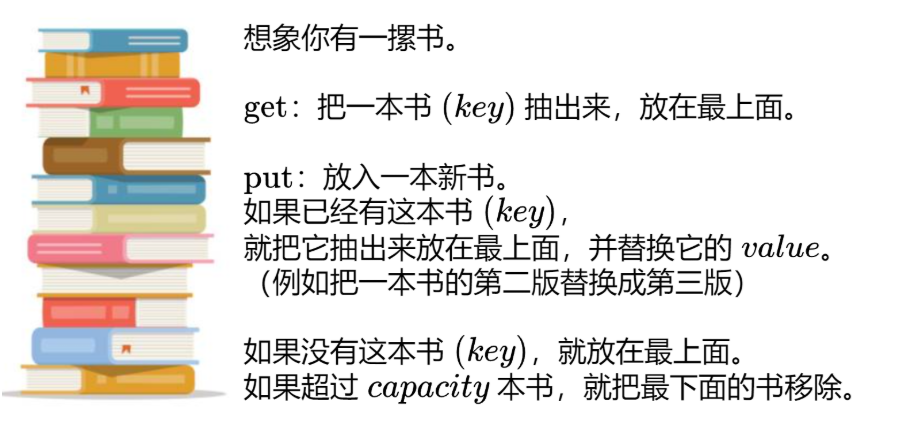

In [38]:
cache = collections.OrderedDict()
cache['1'] = 8
cache['7'] = 25
cache['1'] = 7
cache['7'] = 29
cache.move_to_end('7',last=False)
cache

OrderedDict([('7', 29), ('1', 7)])

In [ ]:
import collections
# move_to_end(): 移动位置
# popitem():字典弹出
class LRUCache:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.cache = collections.OrderedDict()   # 记录插入的顺序
        

    def get(self, key: int) -> int:  #没有删除
        if key in self.cache:
            self.cache.move_to_end(key,last=False)  #实现LRU是有合适的数据结构
            return self.cache[key]
        else:
            return -1
        

    def put(self, key: int, value: int) -> None:
        self.cache[key] = value
        self.cache.move_to_end(key,last=False)
        if len(self.cache) > (self.capacity):
            self.cache.popitem()

### 124. 二叉树中的最大路径和
> 给你一个二叉树的根节点 root, 返回其最大路径和。

- 思路：最大路径的可能情况：左子树的最大路径，右子树的最大路径，或通过根结点的最大路径。  
其中通过根结点的最大路径值等于以左子树根结点为端点的最大路径值加以右子树根结点为端点的最大路径值再加上根结点值，这里还要考虑有负值的情况即负值路径需要丢弃不取。 
转态转移(空间优化)：self.maxPath = max(self.maxPath, node.val + max(0, end_l) + max(0, end_r), end_l, end_r)

把这题背下来，递归实现，分治思想。

In [ ]:
def maxPathSum(root) -> int:
    # 不经过空间优化这题好理解
    maxPath = []
    maxPath.append(float('-inf'))
    
    def largest_path_to_ends(node):
        if not node: return float('-inf')
        
        end_l = largest_path_to_ends(node.left)
        end_r = largest_path_to_ends(node.right)
        
        maxPath.append(max(maxPath[-1], node.val+max(0,end_l)+ max(0,end_r),end_l, end_r)) # maxPath是dp表
        return node.val + max(end_l, end_r,0)
    
    largest_path_to_ends(root)
    
    print(maxPath)
    # return maxPath
    

### 236. 二叉树的最近公共祖先
> 给定一个二叉树, 找到该树中两个指定节点的最近公共祖先。

思路：分治法(某个子树是整体)，有左子树的公共祖先或者有右子树的公共祖先，就返回子树的祖先，否则返回根节点


In [ ]:
class TreeNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None
def lowestCommonAncestor(root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
    if not root: return None
    if root == p or root == q: return root
    
    l = lowestCommonAncestor(root.left,p,q)
    r = lowestCommonAncestor(root.right,p,q)
    if l and r: return root
    elif l: return l
    elif r: return r
    else: return None

### 在一个由 '0' 和 '1' 组成的二维矩阵内，找到只包含 '1' 的最大正方形，并返回其面积。
> 在一个由 '0' 和 '1' 组成的二维矩阵内，找到只包含 '1' 的最大正方形，并返回其面积。

- 思路：这是一个二维DP, 如何设计最优子结构呢？用 dp(i,j) 表示以 (i,j) 为右下角，且只包含 1 的正方形的**边长**最大值。最优子结构是：
  - 如果该位置的值是 0，则 dp(i,j)=0
  - 如果该位置的值是 1，则 dp(i,j)是当前位置的元素值等于三个相邻位置的元素中的最小值加 1
  - 初始化首行首列，保持原样不变即可。  

In [10]:
def maximalSquare(matrix) -> int:
    m,n = len(matrix), len(matrix[0])
    # dp 表
    dp = [[0]*n for _ in range(m)]
    MaxSide = 0
    # dp 初始化首行        # 初始化首列  写在了循环里，更加高效。初始为0，更有意义
    # 状态转移矩阵
    for i in range(m):
        for j in range(n):
            if matrix[i][j] == '1':
                if i==0 or j==0:
                    dp[i][j] = 1
                else:
                    dp[i][j] = min(dp[i-1][j-1], dp[i-1][j], dp[i][j-1]) + 1
                MaxSide = max(MaxSide,dp[i][j])
    print(MaxSide)
    return MaxSide**2
    
    
matrix = [["1","0","1","0","0"],["1","0","1","1","1"],["1","1","1","1","1"],["1","0","0","1","0"]]
maximalSquare(matrix)

2


4

空间复杂度：O(mn),由于状态转移方程中的 dp(i,j) 由其上方、左方和左上方的三个相邻位置的 dp 值决定，因此可以使用两个一维数组进行状态转移，空间复杂度优化至 O(n)。代码省略

### 笔试补充，好数、好串。
> 这种题要往已经学过的DP/滑动窗口/二分查找、单调栈、单调队列上套，如果套不上去，暴力做要么超时，要么内存超限。

### 补充题：88. 合并两个有序数组
> 原地合并两个有序数组，时间复杂度O(m+n)

思路：指针反向遍历，每次取两者之中的较大者放进 nums1的最后面。

In [ ]:
def merge(nums1, m: int, nums2, n: int) -> None:
        """
        Do not return anything, modify nums1 in-place instead.
        """
        i,j = m-1, n-1
        tail = len(nums1)-1
        while i>=0 and j >=0:
            if nums1[i] > nums2[j]:
                nums1[tail] = nums1[i]
                i -= 1
            else:
                nums1[tail] = nums2[j]
                j -= 1
            tail -= 1
        # print(i,j,tail)
        while j >=0:
            nums1[tail] = nums2[j]
            j -=1
            tail -= 1
        # print(nums1)
nums1 = [2,2,3,0,0,0]
m = 3
nums2 = [1,5,6]
n = 3
merge(nums1, m, nums2, n)
nums1

### 56. 合并区间
>以数组 intervals 表示若干个区间的集合，其中单个区间为 intervals[i] = [starti, endi] 。请你合并所有重叠的区间，并返回 一个不重叠的区间数组，该数组需恰好覆盖输入中的所有区间 。

- 思路：以x[0] sort一下。然后intervals合并。主要是比较start_i 和 end_i-1。

In [30]:
def merge(intervals):
    intervals.sort(key= lambda x:x[0])
    # print(intervals)
    lats_start, last_end = intervals[0][0], intervals[0][1]
    results = []
    for i in range(1,len(intervals)):
        start, end = intervals[i]
        if start <=  last_end:
            last_end = max(last_end, end)
        else:
            results.append([lats_start, last_end])
            lats_start, last_end = intervals[i][0], intervals[i][1]
    # 最后一个没判断。加上就好了
    results.append([lats_start, last_end])
    
    return results
        
 
intervals = [[1,3],[2,6],[8,10],[10,18]]
merge(intervals)

[[1, 6], [8, 18]]

### 94. 二叉树的中序遍历
> 给定一个二叉树的根节点 root, 返回它的中序遍历。

- 思路1: 递归写法，dfs思想

In [33]:
def inorderTraversal(root):
    inorder = []
    def dfs(root):
        if not root: return root
        
        dfs(root.left)
        inorder.append(root.val)
        dfs(root.right)
        
    dfs(root) 
    
    return inorder

- 思路2：迭代，通过栈这种数据结构(常考)

In [34]:

def inorderTraversal(root):
    stack, inorder = [], []
    node = root
    while node or stack:
        if node:
            stack.append(node)
            node = node.left
        elif stack:
            node = stack.pop()
            inorder.append(node.val)
            node = node.right
            
    return inorder

### 695. 岛屿的最大面积
> 给你一个大小为 m x n 的二进制矩阵 grid 。找出岛屿的最大面积。这个和200. 岛屿数量是一个模版。

- 思路：这题和200. 岛屿数量就是一个解法，可以一次性学会两题

In [35]:

def maxAreaOfIsland(grid) -> int:
    def dfs_iter(i,j):
        visited = [(i,j)]
        area = 0
        while visited:
            i,j = visited.pop()
            if grid[i][j] == 1:
                if i-1 >=0:
                    visited.append((i-1, j))
                if j-1 >=0:
                    visited.append((i, j-1))
                if i+1 <n:
                    visited.append((i+1, j))
                if j +1 <m:
                    visited.append((i, j+1))
                # post
                grid[i][j] = 0
                # 求最大面积
                area += 1
        return area
    
    n,m = len(grid), len(grid[0])
    # islands_cnt = 0
    max_area = 0
    for i in range(n):
        for j in range(m):
            if grid[i][j] == 1:
                # islands_cnt += 1
                area = dfs_iter(i,j)
                print(area)
                max_area = max(max_area,area)
                
    return max_area

### 20. 有效的括号
> 给定一个只包括 '('，')'，'{'，'}'，'['，']' 的字符串 s ，判断字符串是否有效。

- 思路：由于后遇到的左括号要先闭合，因此可以将这个左括号放入栈顶。右括号为key, 左括号为value
  
栈弹出前要考虑栈是否空

In [8]:
def isValid(s: str) -> bool:
    hashmap = {")":"(", "}":"{", "]":"["}
    stack = []
    for i in range(len(s)):
        char = s[i]
        if stack and char in hashmap:
            # 提前终止
            if hashmap[char] == stack[-1]:
                stack.pop()
            else:
                return False
        else:
            stack.append(char)
            
    return not stack
    
s = ")"
isValid(s)

False

### 152. 乘积最大子数组
> 给你一个整数数组 nums ，请你找出数组中乘积最大的非空连续子数组，并返回该子数组所对应的乘积。

- 思路：间接dp，在求出所有dp_max[i]解的同时，记录最大值。
  
这题和53. 最大子数组和是一个模版, 是53题的延伸题

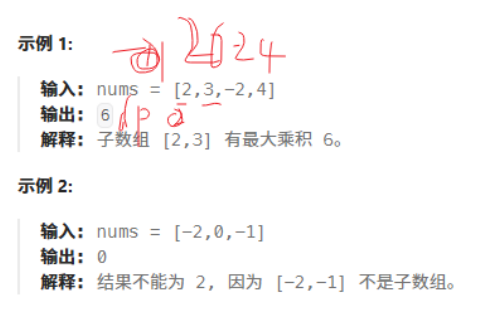

In [30]:
def maxProduct(nums) -> int:
    # dp 表
    dp_max = [0]*len(nums)
    dp_min = [0]*len(nums)
    # 初始化
    dp_max[0] = dp_min[0] = nums[0]
    # 状态转移
    res = nums[0]
    for i in range(1,len(nums)):
        dp_max[i] = max(dp_max[i-1]*nums[i], dp_min[i-1]*nums[i],nums[i])
        dp_min[i] = min(dp_max[i-1]*nums[i], dp_min[i-1]*nums[i],nums[i])
        res = max(res,dp_max[i])
    
    print(dp_max)
    print(dp_min)
    return res
        
    

nums = [2,3,-2,4]
# nums = [-2,0,-1]
# nums = [2,-5,-2,-4,3]
maxProduct(nums)


[2, 6, -2, 4]
[2, 3, -12, -48]


6

### 143. 重排链表
> 给定一个单链表 L 的头节点 head ，单链表L表示为：0,1,2,3,4变为0,4,1,3,2。

- 思路，找到中点findMid(head), 反转后半部分reverseList(head), 合并这两个链表mergeTwoList(head1,head2)

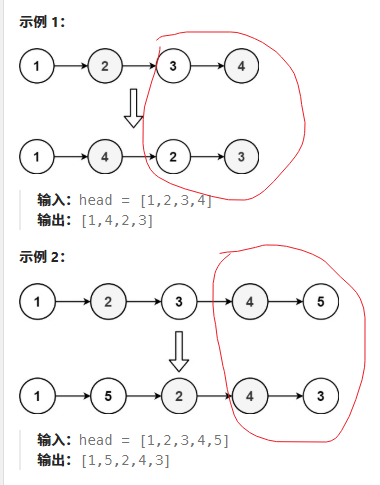

In [ ]:
def reorderList(head) -> None:
    def findMid(head):
        fast,slow = head.next,head
        while fast and fast.next:
            slow =slow.next
            fast = fast.next.next
        return slow
    def reverseList(head):
        new_head = None
        while head:
            nex = head.next
            head.next = new_head
            new_head = head
            head = nex
            
        return new_head
    def mergeTwoList(head1,head2):
        tail = dummy = ListNode(0)
        start_head1 = True
        while head1 or head2:
            if start_head1:
                tail.next = head1
                head1 = head1.next
            else:
                tail.next = head2
                head2 = head2.next
                
            tail = tail.next
            start_head1 = not start_head1
            
        return dummy.next
    
    mid_node = findMid(head)
    right = mid_node.next
    mid_node.next = None
    # 反转右边 + 合并
    return mergeTwoList(head, reverseList(right))
    
    

### 34. 在排序数组中查找元素的第一个和最后一个位置
> 给你一个按照非递减顺序排列的整数数组 nums，和一个目标值 target。请你找出给定目标值在数组中的开始位置和结束位置。如果数组中不存在目标值 target，返回 [-1, -1]。  

- 思路，这是一个典型的二分查找题，有多种实现方式，下面使用模版3实现的，需要注意的是，要用两遍二分查找。

In [60]:
def searchRange(nums, target: int):
    # or 的短路机制导致 nums[0] 未被访问。
    if not nums or target > nums[-1] or target< nums[0]:
        return [-1,-1]
    range = [-1,-1]
    l,r = 0, len(nums)-1
    while l+1 <r:
        mid = l + (r-l) //2
        if nums[mid]<target:
            l = mid
        else:
            r = mid
    print(r)
    if nums[l] == target:
        range[0] = l
    elif nums[r] == target:
        range[0] = r
    else:
        return range
        
    # 找到最右边的下标
    l,r = 0, len(nums)-1
    while l+1 <r:
        mid = l + (r-l) //2
        if nums[mid]<=target:
            l = mid
        else:
            r = mid
    print(r)   
    if nums[r] == target:
        range[1] = r
    elif nums[l] == target:
        range[1] = l
        
    return range
        
    

nums = [2,2]
target = 2
searchRange(nums, target)

1
1


[0, 1]

### 42. 接雨水
> 给定 n 个非负整数表示每个宽度为 1 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。

- 思路：这是leetcode经典题，单调栈(非增)解法一定要回。栈里面存的是下标。面积是currWidth * currHeight. 好好理解怎么计算

In [71]:
def trap(height) -> int:
    ans = 0
    stack = []
    for i in range(len(height)):  #i是最右边
        while stack and height[i] > height[stack[-1]]:  # 维护单调非增栈
            top_idx = stack.pop()
            if not stack:  
                break
            left_idx = stack[-1]
            currWidth = i - left_idx -1
            currHeight = min(height[left_idx], height[i]) - height[top_idx]  # height[top_idx]这表示区域的底
            # print(ans)
            ans += currWidth * currHeight
        stack.append(i)
        print(stack)
    return ans
height = [0,1,0,2,1,0,1,3,2,1,2,1]
trap(height)

[0]
[1]
[1, 2]
[3]
[3, 4]
[3, 4, 5]
[3, 4, 6]
[7]
[7, 8]
[7, 8, 9]
[7, 8, 10]
[7, 8, 10, 11]


6

动态规划和双指针解法，代码省略，可以看官方题解。

### 139. 单词拆分
>给你一个字符串s和一个字符串列表wordDict作为字典。如果可以利用字典中出现的一个或多个单词拼接出 s 则返回 true。

- 思路：动态规划。最优子结构是？？？